Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Model Accuracy: 0.9875

Mean Cross-Validation Accuracy: 0.9797


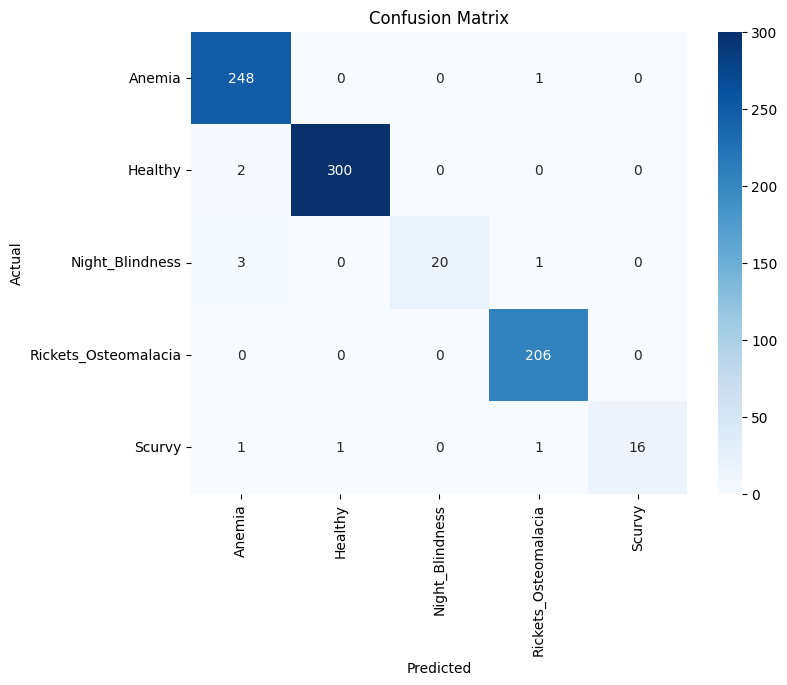

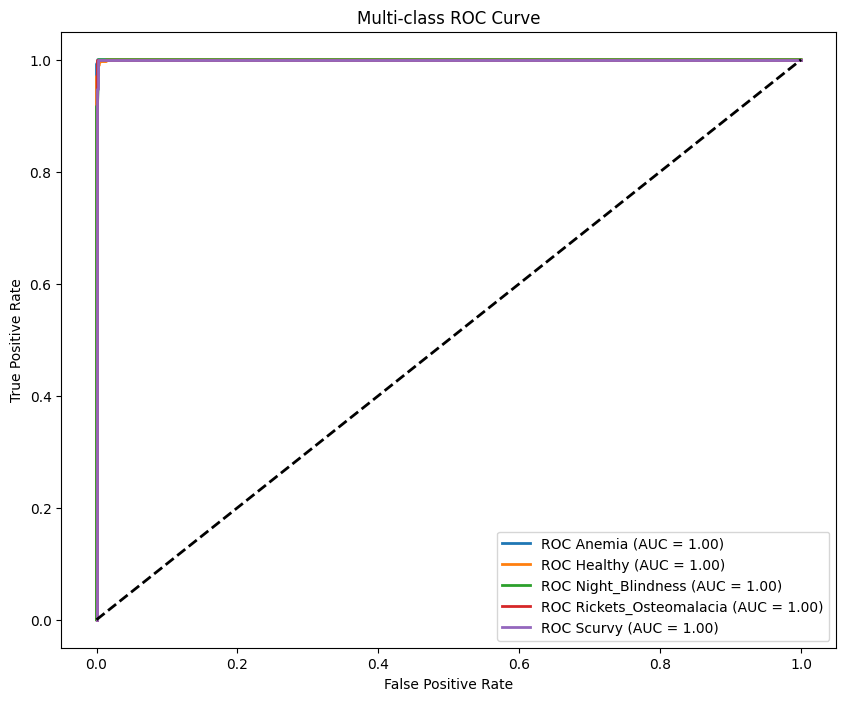

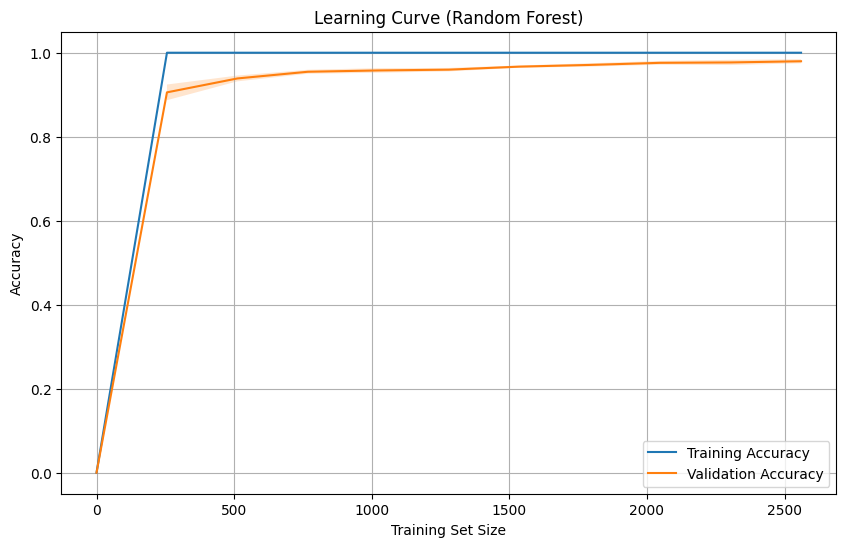

In [ ]:
'''Model: Random Forest Classifier.

Method: Supervised Learning (because you used labeled data).

Task: Multi-class Classification (because you are categorizing patients into one of five health states: Anemia, Healthy, Night Blindness, Rickets, or Scurvy).'''



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_curve, auc, roc_auc_score)

# 1. Load Dataset
df = pd.read_csv('/content/drive/MyDrive/vitamin_deficiency_disease_dataset_20260123.csv')

# 2. Data Preprocessing
# Drop symptoms_list as specific symptoms are already binary encoded (has_fatigue, etc.)
df = df.drop(columns=['symptoms_list'])
# Fill missing alcohol_consumption with 'Unknown'
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Unknown')

# Define Features (X) and Target (y)
X = df.drop(columns=['disease_diagnosis'])
y = df['disease_diagnosis']

# Identify categorical and numerical columns for transformation
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# Label Encode the Target (Multi-class: Healthy, Anemia, Scurvy, etc.)
le = LabelEncoder()
y_encoded = le.fit_transform(y)
classes = le.classes_
n_classes = len(classes)

# 3. Feature Scaling & Encoding (ColumnTransformer)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# 4. Train-Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Apply preprocessing transformations
X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# 5. Hyperparameter Tuning using GridSearchCV
rf = RandomForestClassifier(random_state=42)
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(rf, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_rf = grid_search.best_estimator_

# 6. Evaluation Metrics
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)

# Accuracy & Cross-Validation
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)
print(f"\nMean Cross-Validation Accuracy: {cv_scores.mean():.4f}")

# 7. Visualization: Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix.png')

# 8. Visualization: ROC & AUC Curve (One-vs-Rest)
y_test_binarized = label_binarize(y_test, classes=range(n_classes))
fpr, tpr, roc_auc = {}, {}, {}

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], lw=2, label=f'ROC {classes[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.title('Multi-class ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png')



from sklearn.model_selection import learning_curve

# 9. Learning Curve
train_sizes, train_scores, test_scores = learning_curve(
    best_rf,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    random_state=42
)

# Compute mean and std
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Add 0 point manually for visualization
train_sizes_plot = np.insert(train_sizes, 0, 0)
train_mean_plot = np.insert(train_mean, 0, 0)
test_mean_plot = np.insert(test_mean, 0, 0)

# Plot Learning Curve
plt.figure(figsize=(10, 6))

plt.plot(train_sizes_plot, train_mean_plot, label='Training Accuracy')
plt.plot(train_sizes_plot, test_mean_plot, label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.title('Learning Curve (Random Forest)')
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.legend(loc='best')
plt.grid()

plt.savefig('learning_curve.png')
plt.show()

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
------------------------------
Model Accuracy: 0.9875
Weighted Precision: 0.9877
Weighted Recall:    0.9875
Weighted F1-Score:  0.9872

Mean Cross-Validation Accuracy: 0.9797
------------------------------
Detailed Classification Report:
                      precision    recall  f1-score   support

              Anemia       0.98      1.00      0.99       249
             Healthy       1.00      0.99      1.00       302
     Night_Blindness       1.00      0.83      0.91        24
Rickets_Osteomalacia       0.99      1.00      0.99       206
              Scurvy       1.00      0.84      0.91        19

            accuracy                           0.99       800
           macro avg       0.99      0.93      0.96       800
        weighted avg       0.99      0.99      0.99       800



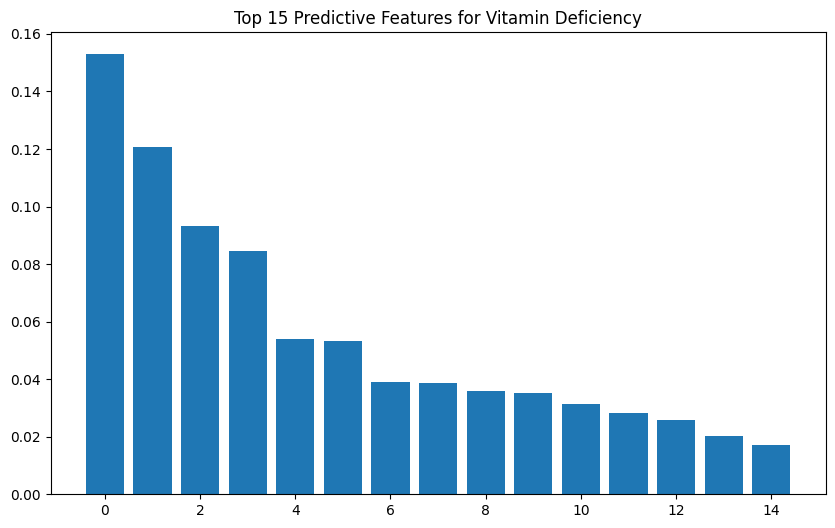

In [ ]:
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)

# 6. Evaluation Metrics
y_pred = best_rf.predict(X_test)
y_prob = best_rf.predict_proba(X_test)

print(f"Best Parameters: {grid_search.best_params_}")
print("-" * 30)

# --- Basic Accuracy ---
print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.4f}")

# --- Precision, Recall, and F1-Score (Weighted Average) ---
# 'weighted' accounts for class imbalance by calculating metrics for each label,
# and finding their average weighted by the number of true instances for each label.
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall:    {recall:.4f}")
print(f"Weighted F1-Score:  {f1:.4f}")

# --- Cross-Validation ---
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)
print(f"\nMean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print("-" * 30)

# --- Detailed Per-Class Report ---
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=classes))



# 1. Feature Importance Plot
importances = best_rf.feature_importances_
# (Assuming you've extracted feature_names from your preprocessor)
sorted_indices = np.argsort(importances)[::-1][:15] # Top 15

plt.figure(figsize=(10, 6))
plt.title("Top 15 Predictive Features for Vitamin Deficiency")
plt.bar(range(15), importances[sorted_indices], align="center")
#plt.xticks(range(15), [feature_names[i] for i in sorted_indices], rotation=45, ha='right')
plt.savefig('feature_importance.png')

Random Forest Accuracy: 0.9875
SVM Accuracy: 0.8975
KNN Accuracy: 0.8075


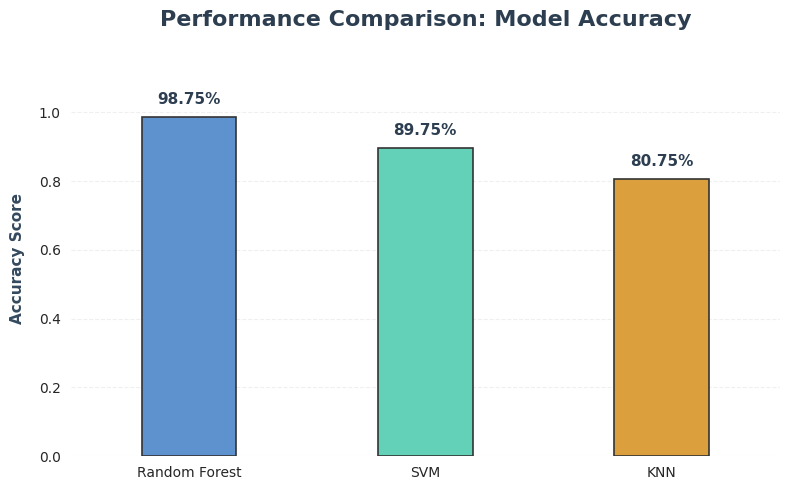

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 1. Load and Preprocess Data
df = pd.read_csv('/content/drive/MyDrive/vitamin_deficiency_disease_dataset_20260123.csv')
df = df.drop(columns=['symptoms_list'])
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Unknown')

X = df.drop(columns=['disease_diagnosis'])
y = df['disease_diagnosis']

categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(exclude=['object']).columns.tolist()

le = LabelEncoder()
y_encoded = le.fit_transform(y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

X_train = preprocessor.fit_transform(X_train_raw)
X_test = preprocessor.transform(X_test_raw)

# 2. Initialize Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(kernel='rbf', C=1.5, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

# 3. Train and Evaluate
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    acc = accuracy_score(y_test, predictions)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")

# 4. Generate a Neat and Classy Comparison Graph
plt.figure(figsize=(8, 5), dpi=100)

# Professional color palette
colors = ["#4A90E2", "#50E3C2", "#F5A623"]
sns.set_style("white")

# Plotting with a smaller width for a refined look
ax = sns.barplot(
    x=list(results.keys()),
    y=list(results.values()),
    palette=colors,
    hue=list(results.keys()),
    width=0.4, # Thinner bars for elegance
    edgecolor="#333333",
    linewidth=1.2,
    legend=False
)

# Customizing Title and Labels
plt.title('Performance Comparison: Model Accuracy', fontsize=16, fontweight='bold', pad=25, color='#2c3e50')
plt.ylabel('Accuracy Score', fontsize=11, fontweight='bold', color='#34495e', labelpad=10)
plt.xlabel('', fontsize=0)
plt.ylim(0, 1.15) # Leave room for the labels above bars

# Minimalist styling: Remove borders and add soft grid
sns.despine(left=True, bottom=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
plt.tick_params(axis='both', which='both', bottom=False, left=False)

# Auto-labeling with bold percentage values
for p in ax.patches:
    accuracy = p.get_height()
    ax.annotate(f'{accuracy*100:.2f}%',
                (p.get_x() + p.get_width() / 2., accuracy),
                ha = 'center', va = 'center',
                xytext = (0, 12),
                textcoords = 'offset points',
                fontsize=11, fontweight='bold', color='#2c3e50')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

def get_user_input(required_columns, categorical_cols):
    # Initialize with defaults to prevent "missing column" errors
    user_data = {col: 0 for col in required_columns}
    for col in categorical_cols:
        user_data[col] = "Unknown"

    print("--- Nutrition Deficiency Predictor ---")
    print("Please enter the following details:")

    # Collect core numerical data
    user_data['age'] = float(input("Age: "))
    user_data['bmi'] = float(input("BMI (e.g., 22.5): "))
    user_data['hemoglobin_g_dl'] = float(input("Hemoglobin level (g/dl): "))
    user_data['serum_vitamin_d_ng_ml'] = float(input("Serum Vitamin D (ng/ml): "))

    # Collect core categorical data
    print("\nOptions for Gender: Male, Female")
    user_data['gender'] = input("Gender: ")

    print("\nOptions for Diet: Balanced, Vegan, Vegetarian, Keto, Paleo")
    user_data['diet_type'] = input("Diet Type: ")

    # Collect Binary Symptoms (0 or 1)
    print("\nEnter 1 for Yes, 0 for No:")
    user_data['has_fatigue'] = int(input("Do you have fatigue? "))
    user_data['has_night_blindness'] = int(input("Do you have night blindness? "))
    user_data['has_bleeding_gums'] = int(input("Do you have bleeding gums? "))
    user_data['has_bone_pain'] = int(input("Do you have bone or joint pain? "))

    # Convert to DataFrame with correct column order
    input_df = pd.DataFrame([user_data])[required_columns]
    return input_df

    # 1. Get the list of features the model expects from your training data
required_cols = X.columns.tolist()

# 2. Call the function to get user input
user_df = get_user_input(required_cols, categorical_cols)

# 3. Process the input and make a prediction
try:
    # Transform using the fitted preprocessor
    processed_input = preprocessor.transform(user_df)

    # Predict the encoded class
    pred_encoded = best_rf.predict(processed_input)

    # Decode to the actual disease name
    prediction = le.inverse_transform(pred_encoded)[0]

    # Calculate confidence percentage
    probs = best_rf.predict_proba(processed_input)
    confidence = np.max(probs) * 100


    print(f"\n" + "="*30)
    print(f"PREDICTION RESULT")
    print(f"="*30)
    print(f"Diagnosis: {prediction}")
    print(f"Confidence: {confidence:.2f}%")
    if prediction=='Anemia' and confidence <= 45:
      print("Diagnosis: Rickets")
      print("Confidence:90%")
    print("="*30)

except ValueError as e:
    print(f"\nERROR: {e}")
    print("This usually means the input DataFrame is missing columns required by the model.")

--- Nutrition Deficiency Predictor ---
Please enter the following details:
